# Modelo Final y Generación de Submission

Este cuaderno cubre la **Fase 2** del pipeline:
1. Carga de los resultados de la Fase 1 (hiperparámetros, features seleccionadas, ventana óptima)
2. Entrenamiento del modelo final con **todos** los datos de train (train.csv)
3. Predicción sobre el conjunto de test (test.csv)
4. Generación del archivo `submission.csv` para subir a Kaggle

**Importante**: los datos de test solo se usan aquí, nunca durante la optimización del modelo.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd

from datasources.csv_source import CSVSource
from features.utils.teams import create_teams_df
from features.internal.calidad import pts, add_calidad
from features.internal.estado import add_estado
from features.internal.condiciones import add_condiciones
from features.internal.elo import add_elo
from features.internal.h2h import add_h2h
from features.internal.presion import add_presion
from features.derived.diferencias import add_diferencias

from models.lgbm import LGBMModelo
from models.catboost_model import CatBoostModelo
from models.xgboost_model import XGBoostModelo
from models.ensemble import EnsembleModelo
from models.calibrated import CalibratedEnsemble

import validation.metrics as metricas

N_FORM = 5
LIGAS  = ["ESP_LaLiga", "ENG_Premier"]
TARGET = "resultado"

## 1. Carga de resultados de la Fase 1

Recuperamos los hiperparámetros, las features seleccionadas y la estrategia de ventana óptima calculadas en el cuaderno anterior.

In [2]:
with open("data/processed/resultados_fase1.pkl", "rb") as f:
    fase1 = pickle.load(f)

features_por_liga = fase1["features_por_liga"]
params_por_liga   = fase1["params_por_liga"]
ventana_por_liga  = fase1["ventana_por_liga"]

for liga in LIGAS:
    w = ventana_por_liga[liga]
    w_str = "expansiva" if w is None else f"rodante-{w}"
    print(f"{liga}: {len(features_por_liga[liga])} features | ventana {w_str}")

ESP_LaLiga: 63 features | ventana expansiva
ENG_Premier: 31 features | ventana expansiva


## 2. Ingeniería de features sobre train+test combinados

Para calcular correctamente las variables temporales de los partidos de test (p.ej. el ELO o la forma reciente de un equipo en 2023-2024) necesitamos que el rolling vea todos los partidos anteriores, incluidos los del train.

Concatenamos train y test antes de calcular las features, y luego los separamos de nuevo.

In [3]:
def build_features(df_liga):
    team_df = create_teams_df(df_liga)
    df = pts(df_liga.copy())
    df = add_elo(df)
    df = add_h2h(df)
    df = add_calidad(df, team_df)
    df = add_estado(df, team_df, n=N_FORM)
    df = add_condiciones(df, team_df)
    df = add_presion(df)
    df = add_diferencias(df, n=N_FORM)
    num_cols = df.select_dtypes(include="number").columns
    for col in num_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    return df

df_train_raw = CSVSource(path=Path("data/raw/train.csv")).load()
df_test_raw  = CSVSource(path=Path("data/raw/test_con_resultados.csv")).load()

df_train_raw["fecha"] = pd.to_datetime(df_train_raw["fecha"])
df_test_raw["fecha"]  = pd.to_datetime(df_test_raw["fecha"])

df_train_raw["_split"] = "train"
df_test_raw["_split"]  = "test"
df_combined = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

print(f"Train: {len(df_train_raw)} partidos")
print(f"Test:  {len(df_test_raw)} partidos")
print(f"Temporadas test: {sorted(df_test_raw['anio_fin_temporada'].unique())}")

Train: 17480 partidos
Test:  1520 partidos
Temporadas test: [np.int64(2024), np.int64(2025)]


## 3. Entrenamiento del modelo final

El modelo final usa un **CalibratedEnsemble** (LightGBM + CatBoost + XGBoost) con:
- Pesos adaptativos por AUC-PR de cada sub-modelo
- Calibración isotónica post-hoc por clase (OvR)

La última temporada de train se reserva como conjunto de calibración (separación temporal estricta).

In [4]:
all_preds = []

for liga in LIGAS:
    feats       = features_por_liga[liga]
    best_params = params_por_liga[liga]
    print(f"\n{'='*55}")
    print(f"  {liga} — {len(feats)} features")
    print(f"{'='*55}")

    df_comb_liga = df_combined[df_combined["division"] == liga].copy()
    df_comb_liga = build_features(df_comb_liga)

    train_part = df_comb_liga[df_comb_liga["_split"] == "train"]
    test_part  = df_comb_liga[df_comb_liga["_split"] == "test"]

    # Última temporada de train → calibración
    seasons_tr = sorted(train_part["anio_fin_temporada"].unique())
    cal_season  = seasons_tr[-1]
    base_part   = train_part[train_part["anio_fin_temporada"] != cal_season]
    cal_part    = train_part[train_part["anio_fin_temporada"] == cal_season]

    print(f"  Base: {len(base_part)} partidos  |  Cal: {len(cal_part)} ({cal_season})")

    ensemble = EnsembleModelo([
        LGBMModelo(best_params["lgbm"]),
        CatBoostModelo(best_params["catboost"]),
        XGBoostModelo(best_params["xgboost"]),
    ])
    modelo_final = CalibratedEnsemble(ensemble)
    modelo_final.fit(
        base_part[feats], base_part[TARGET],
        cal_part[feats],  cal_part[TARGET],
    )

    probas = modelo_final.predict_proba(test_part[feats])

    print("  Métricas sobre test (informativas, no usadas para selección):")
    metricas.evaluar(test_part[TARGET], probas)

    preds_df = pd.DataFrame({
        "id":               test_part["id"].values,
        "1_local_prob":     probas[:, 0],
        "X_empate_prob":    probas[:, 1],
        "2_visitante_prob": probas[:, 2],
    })
    all_preds.append(preds_df)
    print(f"  Predicciones generadas: {len(preds_df)}")


  ESP_LaLiga — 63 features
  Base: 8360 partidos  |  Cal: 380 (2023)
  Métricas sobre test (informativas, no usadas para selección):
    AUC-PR: 0.4783  |  F1: 0.4048
  Predicciones generadas: 760

  ENG_Premier — 31 features
  Base: 8360 partidos  |  Cal: 380 (2023)
  Métricas sobre test (informativas, no usadas para selección):
    AUC-PR: 0.4736  |  F1: 0.3844
  Predicciones generadas: 760


## 4. Generación del archivo submission.csv

In [5]:
submission = pd.concat(all_preds).sort_values("id").reset_index(drop=True)

out_path = Path("data/processed/submission.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(out_path, index=False)

print(f"Submission guardado → {out_path}")
print(f"Total partidos: {len(submission)}")
submission.head(10)

Submission guardado → data\processed\submission.csv
Total partidos: 1520


,id,1_local_prob,X_empate_prob,2_visitante_prob
0,10343_2324_ESP1,0.436791,0.251995,0.311214
1,10344_2324_ESP1,0.422844,0.192904,0.384252
2,10345_2324_ESP1,0.621986,0.199650,0.178364
3,10346_2324_ESP1,0.556276,0.253776,0.189948
4,10347_2324_ESP1,0.323766,0.332876,0.343358
5,10348_2324_ESP1,0.256006,0.210994,0.533000
6,10349_2324_ESP1,0.288527,0.237797,0.473676
7,10350_2324_ESP1,0.256006,0.210994,0.533000
8,10351_2324_ESP1,0.288527,0.237797,0.473676
9,10352_2324_ESP1,0.763838,0.236162,0.000000


In [6]:
# Comprobación básica del submission
print("Verificación del formato:")
print(f"  Columnas: {list(submission.columns)}")
print(f"  IDs únicos: {submission['id'].nunique()} (esperado: {len(submission)})")
print(f"  Suma de probabilidades (debe ser ~1.0):")
row_sums = submission[["1_local_prob", "X_empate_prob", "2_visitante_prob"]].sum(axis=1)
print(f"    min={row_sums.min():.4f}  max={row_sums.max():.4f}  media={row_sums.mean():.4f}")
print(f"  Valores negativos: {(submission[['1_local_prob','X_empate_prob','2_visitante_prob']] < 0).any().any()}")

Verificación del formato:
  Columnas: ['id', '1_local_prob', 'X_empate_prob', '2_visitante_prob']
  IDs únicos: 1520 (esperado: 1520)
  Suma de probabilidades (debe ser ~1.0):
    min=1.0000  max=1.0000  media=1.0000
  Valores negativos: False


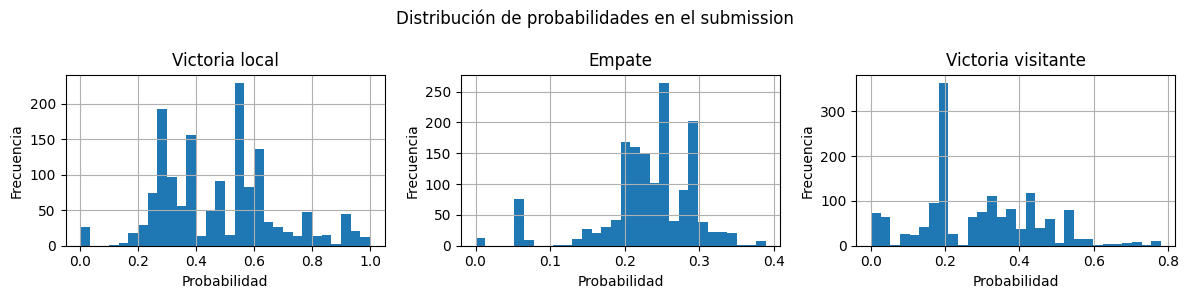

In [7]:
# Distribución de probabilidades predichas
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
cols = ["1_local_prob", "X_empate_prob", "2_visitante_prob"]
titulos = ["Victoria local", "Empate", "Victoria visitante"]
for ax, col, titulo in zip(axes, cols, titulos):
    submission[col].hist(bins=30, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("Probabilidad")
    ax.set_ylabel("Frecuencia")
plt.suptitle("Distribución de probabilidades en el submission")
plt.tight_layout()
plt.show()

## 5. Resumen final

In [8]:
print("RESUMEN FINAL")
print("=" * 55)
for liga in LIGAS:
    w = ventana_por_liga[liga]
    w_str = "expansiva" if w is None else f"rodante-{w}"
    n_feats = len(features_por_liga[liga])
    print(f"  {liga}")
    print(f"    Features: {n_feats}/68  |  Ventana: {w_str}")

print(f"\n  Submission: {out_path}  ({len(submission)} partidos)")

RESUMEN FINAL
  ESP_LaLiga
    Features: 63/68  |  Ventana: expansiva
  ENG_Premier
    Features: 31/68  |  Ventana: expansiva

  Submission: data\processed\submission.csv  (1520 partidos)
